![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 01 | Exploratory Data Analysis

*Project 1 — SQL: From Data to Insight*

**Student:** Gabriel Gomes

**Dataset:** Inside Airbnb (Rio de Janeiro)

---

# Introduction

## Questions

## Dataset Description

The data is the latest of the periodic snapshots of every Airbnb listing in Rio de Janeiro, taken on June 24th, 2026, and published by [Inside Airbnb](https://insideairbnb.com/).

Since Rio is my hometown, I located the corresponding data page (`https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2026-06-24/`) and adapted the `download_data.py` script to fetch the datasets from it.

While browsing the site, I found additional datasets that broaden the scope of the project. The files used throughout the project are listed below:

| File | Rows | Columns | Description |
|---|---|---|---|
| `listings.csv.gz` | 48,713 | 90 | One row per listing. Columns include price, room type, neighborhood, host, review scores, and availability. |
| `reviews.csv.gz` | 1,388,472 | 6 | One row per review. Columns include `listing_id`, `date`, `reviewer_id`, `reviewer_name`, and `comments`. |
| `neighbourhoods.csv` | 160 | 2 | One row per neighborhood. Columns include the neighborhood name. |
| `neighbourhoods.geojson` | 160 | 3 | One row per neighborhood. Columns include the neighborhood name and its geometry. |




# Setup

## Importing libraries

In [2]:
import sys
sys.path.append("..")          

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

%load_ext autoreload
%autoreload 2
from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

In [3]:
# Set the Seaborn context to "poster" for larger text and figures
sns.set_context("poster")

# Set the default figure size for Seaborn plots
sns.set(rc={"figure.figsize": (12., 6.)})

# Set the Seaborn style to "whitegrid" for a white background with gridlines
sns.set_style("whitegrid")

# 1.  First Look

To conduct the exploratory data analysis, we first need to load the raw datasets into pandas DataFrames. Besides the data provided by Inside Airbnb, I also needed a table mapping each neighborhood (*bairro*, in Portuguese) in Rio to its corresponding planning area, which will be used later on.

Since I could not find a ready-made CSV online, I used Claude to convert the [PDF published by the Rio city government](https://www.rio.rj.gov.br/dlstatic/10112/5148142/4145881/ListadeBairroseAPs_Mapa) into a CSV table, which I then saved in my raw data directory.

In [4]:
listings_raw = pd.read_csv("../data/raw/listings.csv.gz")
reviews_raw = pd.read_csv("../data/raw/reviews.csv.gz")
neighborhoods_raw = pd.read_csv("../data/raw/neighbourhoods.csv")
neighborhoods_geo_raw = gpd.read_file("../data/raw/neighbourhoods.geojson")
bairros = pd.read_csv("../data/raw/bairros.csv")

## DataFrames Info

Next, let's examine the structure of each DataFrame: its columns, the data type of each column, and the number of non-null values.


In [5]:
listings_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48713 entries, 0 to 48712
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            48713 non-null  int64  
 1   listing_url                                   48713 non-null  str    
 2   scrape_id                                     48713 non-null  int64  
 3   last_scraped                                  48713 non-null  str    
 4   source                                        48713 non-null  str    
 5   name                                          48713 non-null  str    
 6   description                                   47704 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   48713 non-null  str    
 9   host_id                                       48713 non-null  int64  
 1

In [6]:
reviews_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1388472 entries, 0 to 1388471
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   listing_id     1388472 non-null  int64
 1   id             1388472 non-null  int64
 2   date           1388472 non-null  str  
 3   reviewer_id    1388472 non-null  int64
 4   reviewer_name  1388468 non-null  str  
 5   comments       1388435 non-null  str  
dtypes: int64(3), str(3)
memory usage: 386.6 MB


In [7]:
neighborhoods_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  0 non-null      float64
 1   neighbourhood        160 non-null    str    
dtypes: float64(1), str(1)
memory usage: 4.3 KB


In [8]:
neighborhoods_geo_raw.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   neighbourhood        160 non-null    str     
 1   neighbourhood_group  0 non-null      object  
 2   geometry             160 non-null    geometry
dtypes: geometry(1), object(1), str(1)
memory usage: 5.6+ KB


## Samples

Next, let's get a feel for the data by looking at 10 random rows from each DataFrame, to understand what kind of information each column holds.


In [9]:
listings_raw.sample(10)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
19054,1605020246916997506,https://www.airbnb.com/rooms/1605020246916997506,20260624212719,2026-06-26,city scrape,Copacabana | Vista mar | Praia,Rio Select is an elegant apartment in Copacaba...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,170893560,https://www.airbnb.com/users/show/170893560,1.468661e+18,https://www.airbnb.com/users/profile/146866090...,Lumy Hospedagens,NaN,8.0,4.0,3.0,3.0,NaN,"Na Lumy Hospedagens, somos especialistas em lo...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,8.0,NaN,NaN,t,t,NaN,Copacabana,NaN,-22.961410,-43.176200,Entire rental unit,Entire home/apt,4,1.0,1 bath,1.0,2.0,"[""Portable fans"", ""Private entrance"", ""Coffee ...",$324.50,2026-06-29,2026-07-01,649.00,324.50,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",2.0,90.0,2.0,5.0,90.0,90.0,2.2,90.0,NaN,t,20,44,71,345,2026-06-26,10,10,2,170,0,60,19470.0,2026-02-07,2026-06-21,4.70,4.80,4.80,5.00,5.00,4.70,4.70,NaN,NaN,6,6,0,0,2.14
11011,1682213884450103960,https://www.airbnb.com/rooms/1682213884450103960,20260624212719,2026-06-26,city scrape,Casa Serena | Nagib Hospedagem,"Refúgio da Lapa, Comfort and charm in the hear...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,653048107,https://www.airbnb.com/users/show/653048107,1.470642e+18,https://www.airbnb.com/users/profile/147064201...,Fátima Nagib,NaN,1.0,9.0,1.0,9.0,NaN,NaN,NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,7.0,NaN,NaN,t,t,NaN,Centro,NaN,-22.909830,-43.178020,Entire rental unit,Entire home/apt,4,1.0,1 bath,1.0,2.0,"[""Single level home"", ""Private entrance"", ""Cof...",$239.65,2026-06-26,2026-06-27,239.65,239.65,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",1.0,365.0,1.0,4.0,365.0,365.0,1.1,365.0,NaN,t,21,47,77,257,2026-06-26,5,5,4,176,0,30,7190.0,2026-05-17,2026-06-13,5.00,5.00,5.00,5.00,5.00,4.80,5.00,NaN,NaN,4,4,0,0,3.66
5436,1208739178114831968,https://www.airbnb.com/rooms/1208739178114831968,20260624212719,2026-06-26,city scrape,Apt Guinle II,"Apartment very well located, close to the subw...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,152628911,https://www.airbnb.com/users/show/152628911,1.468497e+18,https://www.airbnb.com/users/profile/146849701...,Sonia,NaN,8.0,8.0,3.0,3.0,"Rio de Janeiro, Brazil",NaN,NaN,NaN,NaN,f,NaN,https://a0.musca

In [10]:
reviews_raw.sample(10)

,listing_id,id,date,reviewer_id,reviewer_name,comments
1192643,1316027710846659483,1345034112692557968,2025-01-29,204993564,Matheus,O apartamento foi excelente! Localização impec...
115235,3157407,123469078,2016-12-29,27227349,Livia,"Nilma é uma excelente anfitriã, super atencios..."
1018407,1077585918910944390,1591414357071496663,2026-01-04,731012425,Hans,Tudo conforme combinado.
926883,984608328620435424,1190674048364806011,2024-06-30,303113309,Dandara,"Adorei minha estádia no vidigal, fácil acesso ..."
140947,4915245,429653919199691242,2021-08-15,411171770,Warnold,"Muito bom, gostamos muito, tudo certo."
199758,11011200,225725689,2018-01-07,3319432,Gian Carlo,O apartamento é como apresentado nas fotos. Mu...
470316,39779613,1268227999087099145,2024-10-15,458993813,Karly,"Excelente atención, el apartamento muy lindo m..."
69500,2315061,45690262,2015-09-05,39932383,Thomas,We very much enjoyed our stay in Bruno's apart...
1234763,1362360963215398616,1534895691147609223,2025-10-18,95440135,Carhue,"Todo perfecto, tal como lo indicaba la descrip..."
445306,37973801,469527518676516218,2021-10-09,156814755,Tamires,Super


In [11]:
neighborhoods_raw.sample(10)

,neighbourhood_group,neighbourhood
140,NaN,Tauá
159,NaN,Zumbi
74,NaN,Jardim América
69,NaN,Irajá
72,NaN,Jacarepaguá
45,NaN,Engenheiro Leal
109,NaN,Pilares
95,NaN,Olaria
66,NaN,Inhaúma
85,NaN,Madureira


In [72]:
neighborhoods_geo_raw.sample(10)

,neighbourhood,neighbourhood_group,geometry
24,Irajá,None,"MULTIPOLYGON Z (((-43.31717 -22.81953 0, -43.3..."
154,Joá,None,"MULTIPOLYGON Z (((-43.27559 -23.00329 0, -43.2..."
79,Vila Valqueire,None,"MULTIPOLYGON Z (((-43.36927 -22.87724 0, -43.3..."
55,Padre Miguel,None,"MULTIPOLYGON Z (((-43.44555 -22.87533 0, -43.4..."
70,Manguinhos,None,"MULTIPOLYGON Z (((-43.23924 -22.8799 0, -43.23..."
19,Praia da Bandeira,None,"MULTIPOLYGON Z (((-43.17744 -22.80792 0, -43.1..."
95,Vasco da Gama,None,"MULTIPOLYGON Z (((-43.22749 -22.88515 0, -43.2..."
109,Cidade Nova,None,"MULTIPOLYGON Z (((-43.19511 -22.91174 0, -43.1..."
23,Cacuia,None,"MULTIPOLYGON Z (((-43.1862 -22.81066 0, -43.18..."
9,Campo Grande,None,"MULTIPOLYGON Z (((-43.49622 -22.81374 0, -43.4..."


To see what the `geometry` column actually stores, let's plot the GeoJSON neighborhoods DataFrame. The result is a map in which each neighborhood appears as a delimited area, side by side with its neighbors.

In [73]:
pd.set_option("display.max_colwidth", 50)


In [74]:
neighborhoods_geo_raw

,neighbourhood,neighbourhood_group,geometry
0,Paquetá,None,"MULTIPOLYGON Z (((-43.10567 -22.74888 0, -43.1..."
1,Freguesia (Ilha),None,"MULTIPOLYGON Z (((-43.1717 -22.77661 0, -43.17..."
2,Bancários,None,"MULTIPOLYGON Z (((-43.18915 -22.78318 0, -43.1..."
3,Galeão,None,"MULTIPOLYGON Z (((-43.22804 -22.78374 0, -43.2..."
4,Portuguesa,None,"MULTIPOLYGON Z (((-43.20763 -22.79498 0, -43.2..."
...,...,...,...
155,Barra de Guaratiba,None,"MULTIPOLYGON Z (((-43.52203 -23.0078 0, -43.52..."
156,Grumari,None,"MULTIPOLYGON Z (((-43.50815 -23.0331 0, -43.50..."
157,Caju,None,"MULTIPOLYGON Z (((-43.22518 -22.87464 0, -43.2..."
158,Deodoro,None,"MULTIPOLYGON Z (((-43.37902 -22.85022 0, -43.3..."


In [71]:
pd.reset_option("display.max_colwidth")

# 2. Data Quality

The next goal is to spot missing values, duplicates, and data type inconsistencies, such as numbers stored as text or dates stored as strings. The `get_quality` function is our main tool at this stage: it produces a table that quantifies the problems in each DataFrame's columns.

The quality table for the `listings` DataFrame below shows that several columns contain only null values. These will be dropped later, at the data cleaning stage.

Inspecting the data type of each column also reveals inconsistencies in the same DataFrame. They include strings that should be booleans (`host_is_superhost`), strings that should be floats (`price`), and integers that should be floats (`minimum_nights`). These conversions are noted here and will be carried out only if the columns prove relevant to the research questions.

In [14]:
get_quality(listings_raw)

Rows: 48713  |  Columns: 90  |  Duplicated rows: 0


,dtype,nulls,nulls_%,blanks,n_unique
host_response_rate,float64,48713,100.0,0,0
host_neighbourhood,float64,48713,100.0,0,0
host_thumbnail_url,float64,48713,100.0,0,0
host_total_listings_count,float64,48713,100.0,0,0
host_acceptance_rate,float64,48713,100.0,0,0
neighborhood_overview,float64,48713,100.0,0,0
host_response_time,float64,48713,100.0,0,0
host_verifications,float64,48713,100.0,0,0
calendar_updated,float64,48713,100.0,0,0
neighbourhood,float64,48713,100.0,0,0


Repeating the process for the other DataFrames shows that `reviews` is in good shape, with only a few null values across the entire table and consistent data types. In the `neighbourhoods` DataFrame, however, `neighbourhood_group` contains only null values. This column will be filled in later, at the data cleaning stage.

In [15]:
get_quality(reviews_raw)

Rows: 1388472  |  Columns: 6  |  Duplicated rows: 0


,dtype,nulls,nulls_%,blanks,n_unique
reviewer_name,str,4,0.0,0,139492
comments,str,37,0.0,0,1322493


In [16]:
get_quality(neighborhoods_raw)

Rows: 160  |  Columns: 2  |  Duplicated rows: 0


,dtype,nulls,nulls_%,blanks,n_unique
neighbourhood_group,float64,160,100.0,0,0


# 3. Distributions

In the preliminary list of numeric columns below, three groups look promising for the analysis. The first is the listing's price per night (`price_quote_price_per_night`), the second is the number of guests each listing accommodates (`accommodates`), and the third is the seven review scores (`review_scores_*`) that guests give after a stay. Let's explore their distributions.

In [17]:
listings_raw.select_dtypes(include="number").columns

Index(['id', 'scrape_id', 'neighborhood_overview', 'host_id',
       'host_profile_id', 'host_since', 'hosts_time_as_user_years',
       'hosts_time_as_user_months', 'hosts_time_as_host_years',
       'hosts_time_as_host_months', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed',
       'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'price_quote_total_price', 'price_quote_price_per_night',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar_updated', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_revie

A brief overview of these columns, obtained with the `describe` method, already offers some insights:

- The price per night has a maximum value of $574,000. A price this extreme suggests some kind of error and these values will be examined during cleaning. 
- The median price per night of $452.67 is roughly half the mean of $877.71, which indicates a right-skewed distribution driven by a few very expensive listings.
- The maximum guest capacity is 16.
- As expected, the review scores range from 0 to 5, and their averages are high, at around 4.8.

In [18]:
numeric_colums = ['price_quote_price_per_night','accommodates','review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']

listings_raw[numeric_colums].describe()

,price_quote_price_per_night,accommodates,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,44542.000000,48713.000000,38890.000000,38889.000000,38890.000000,38890.000000,38889.000000,38889.000000,38888.000000
mean,877.707421,3.929177,4.805776,4.822588,4.782412,4.888010,4.880676,4.855876,4.733233
std,4599.612177,2.261917,0.379010,0.363851,0.396330,0.305366,0.320955,0.312643,0.412239
min,5.540000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,296.710000,2.000000,4.770000,4.800000,4.730000,4.890000,4.880000,4.830000,4.670000
50%,452.670000,4.000000,4.920000,4.930000,4.900000,4.980000,4.980000,4.950000,4.830000
75%,761.537500,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,574013.000000,16.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [19]:
listings_raw['price_quote_price_per_night'].median()

np.float64(452.67)

A quick calculation also shows that roughly 8.6% of the listing prices are outliers.

In [20]:
quantile_1 = listings_raw['price_quote_price_per_night'].quantile(0.25)
quantile_3 = listings_raw['price_quote_price_per_night'].quantile(0.75)

iqr = quantile_3 - quantile_1

outlier_condition = listings_raw['price_quote_price_per_night'] > quantile_3 + 1.5*iqr

num_outliers = listings_raw['price_quote_price_per_night'][outlier_condition].count()

outlier_fraction = num_outliers/len(listings_raw)
outlier_fraction

np.float64(0.08642456839036808)

The box plot below shows a significant number of outliers, while the bulk of the price per night distribution is hard to see because it is compressed against the left side of the plot.

[Text(0.5, 1.0, 'Distribution of Prices per Night'),
 Text(0.5, 0, 'Price per Night ($)')]

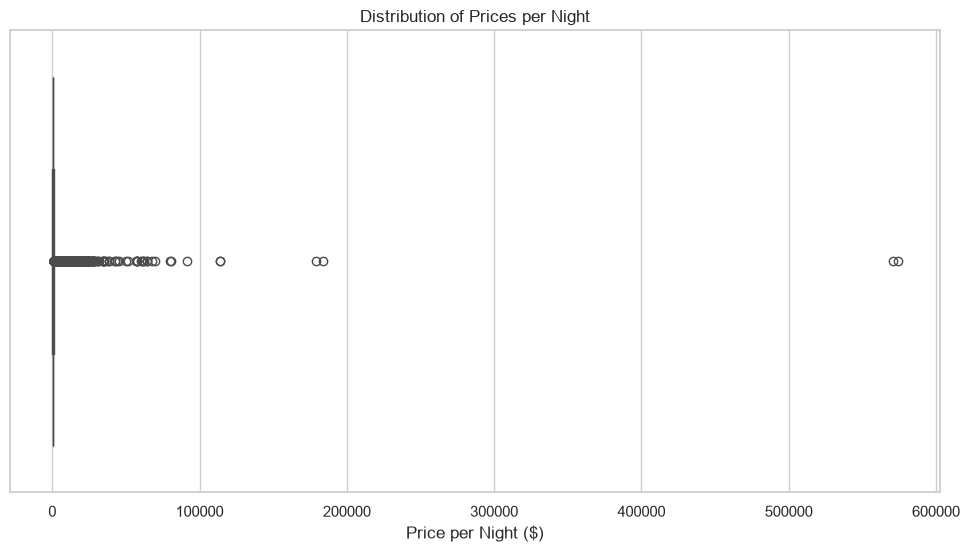

In [21]:
ax = sns.boxplot(data=listings_raw, x='price_quote_price_per_night')
ax.set(
    title="Distribution of Prices per Night",
    xlabel="Price per Night ($)"
)

[Text(0.5, 1.0, 'Distribution of Prices per Night'),
 Text(0.5, 0, 'Price per Night ($)')]

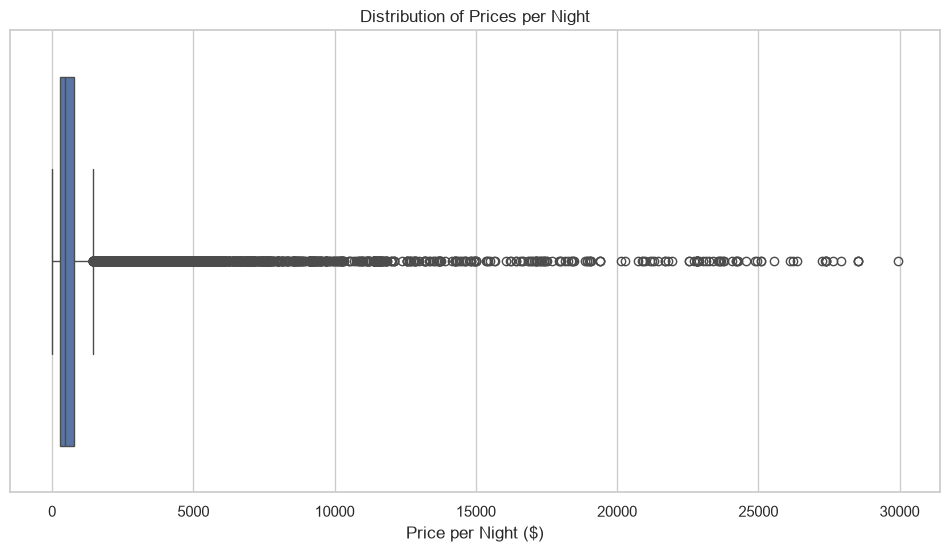

In [61]:
ax = sns.boxplot(data=listings_raw[listings_raw.price_quote_price_per_night < 30000], x='price_quote_price_per_night')
ax.set(
    title="Distribution of Prices per Night",
    xlabel="Price per Night ($)"
)

To address this, we can restrict the price range to get a clearer view of the distribution. Instead of a box plot, let's use a violin plot, which also shows the kernel density estimate. From this plot, we get a better picture of the interquartile range.

[Text(0.5, 1.0, 'Distribution of Prices per Night'),
 Text(0.5, 0, 'Price per Night ($)'),
 (0.0, 10000.0)]

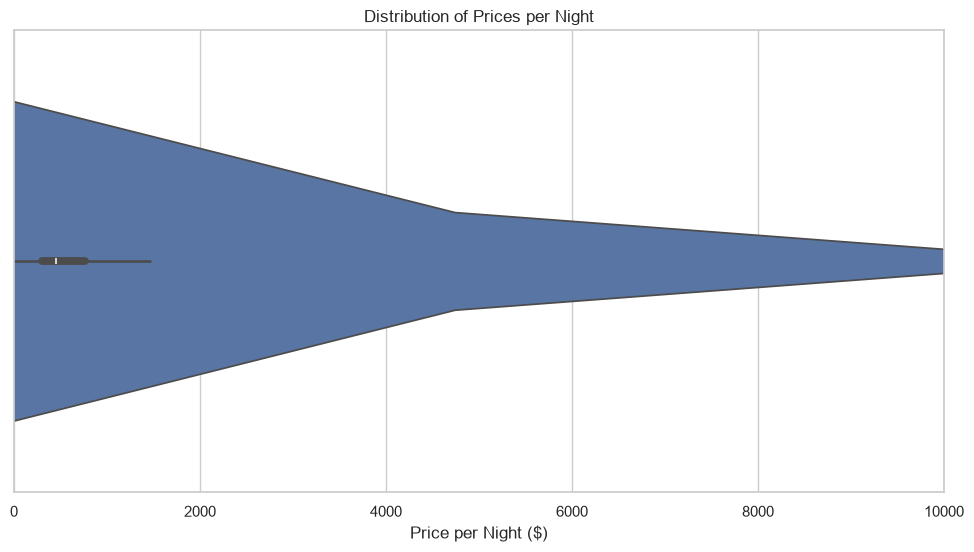

In [22]:
ax = sns.violinplot(data=listings_raw, x='price_quote_price_per_night')
ax.set(
    title="Distribution of Prices per Night",
    xlabel="Price per Night ($)",
    xlim=(0, 10000)
)

[Text(0.5, 1.0, 'Distribution of Guest Capacities'),
 Text(0.5, 0, 'Maximum Guest Capacity')]

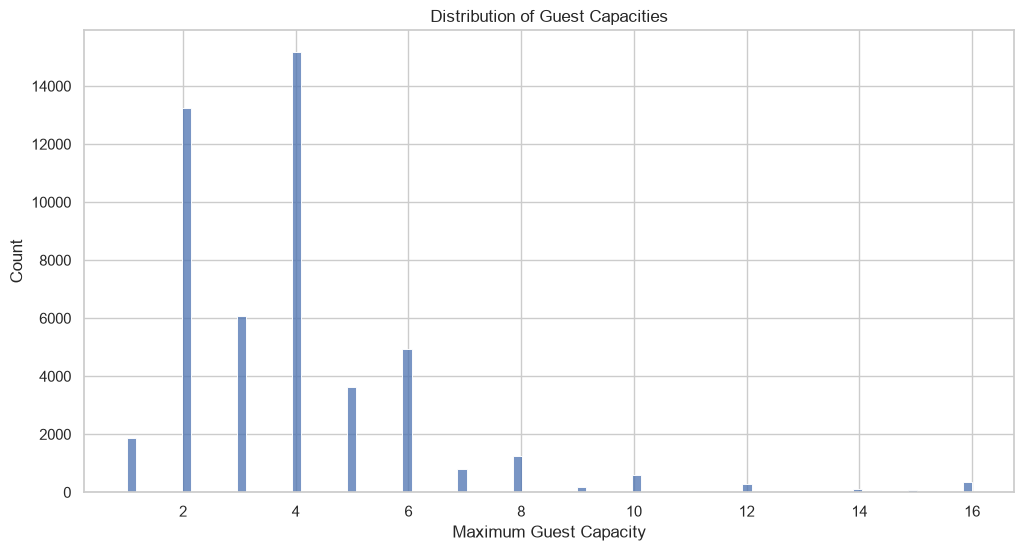

In [23]:
ax = sns.histplot(data=listings_raw, x='accommodates')
ax.set(
    title="Distribution of Guest Capacities",
    xlabel="Maximum Guest Capacity"
)

In [33]:
listings_raw['has_availability'][listings_raw['has_availability']=='f'].count()

np.int64(411)

[Text(0.5, 1.0, 'Distribution of Review Rating Scores'),
 Text(0.5, 0, 'Review Rating Scores')]

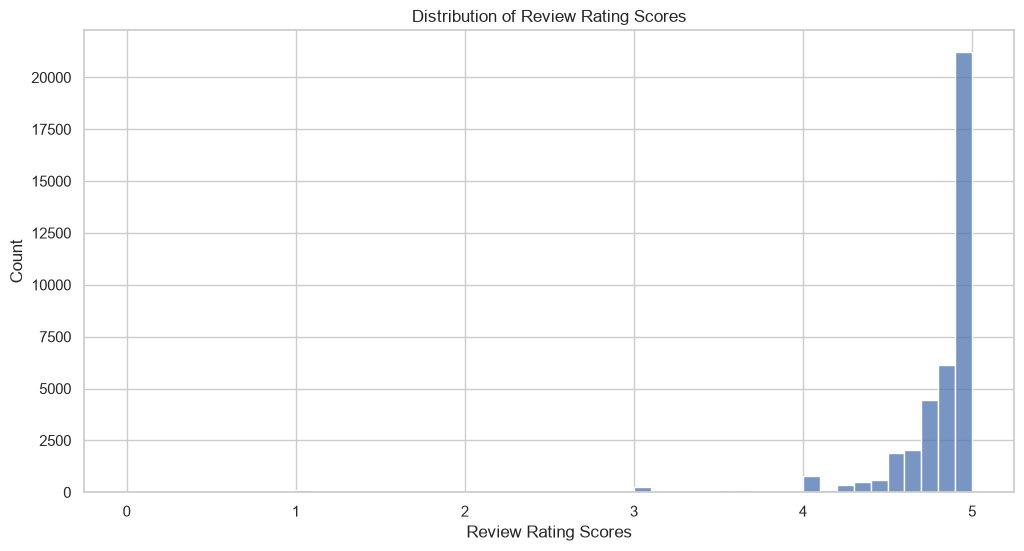

In [24]:
ax = sns.histplot(data=listings_raw, x='review_scores_rating', bins=50)

ax.set(
    title="Distribution of Review Rating Scores",
    xlabel="Review Rating Scores"
)

# 4. Categorical Columns

In [25]:
categorical_columns = listings_raw.select_dtypes(exclude="number").columns
categorical_columns

Index(['listing_url', 'last_scraped', 'source', 'name', 'description',
       'picture_url', 'host_url', 'host_profile_url', 'host_name',
       'host_location', 'host_about', 'host_is_superhost', 'host_picture_url',
       'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'property_type', 'room_type',
       'bathrooms_text', 'amenities', 'price', 'price_quote_checkin_date',
       'price_quote_checkout_date', 'price_quote_raw', 'has_availability',
       'calendar_last_scraped', 'first_review', 'last_review'],
      dtype='str')

Counting the unique values in each categorical column shows that `room_type`, with only 4 unique values, is a good candidate for a lookup table. Although `neighbourhood_cleansed` has 154 unique values, it is also a candidate, with a `neighbourhood_id` replacing the name in the main table to identify each neighborhood.

In [28]:
categorical_unique_count = listings_raw[categorical_columns].nunique()

categorical_unique_count = (
    categorical_unique_count
    .rename("unique_count")
    .rename_axis("column")
    .reset_index()
    .sort_values("unique_count", ascending=True)
)

categorical_unique_count

,column,unique_count
13,host_has_profile_pic,2
2,source,2
24,has_availability,2
11,host_is_superhost,2
14,host_identity_verified,2
1,last_scraped,3
25,calendar_last_scraped,3
17,room_type,4
18,bathrooms_text,48
16,property_type,85


In [27]:
listings_raw['room_type'].unique()

<ArrowStringArray>
['Private room', 'Entire home/apt', 'Shared room', 'Hotel room']
Length: 4, dtype: str

# 5. Research Questions

**Location — Where should I look?**
1. Which neighborhoods (and zones) have the most listings to choose from — i.e., where will I have the widest selection and easiest availability?
2. Which neighborhoods do guests consistently rate highest for location — i.e., where am I most likely to be happy with where I ended up staying?

**Property attributes — What should I book?**

3. Which combination of property attributes gives me the best deal — the highest review scores for the price I'm paying per guest?

**Host characteristics — Who should I book with?**

4. Am I better off booking with a Superhost or a host who manages multiple properties, versus a smaller, non-Superhost listing — do they actually deliver better occupancy (i.e., proven track record) and review scores?

**Timing — When should I visit?**

   5. How does review activity change across the calendar year — are there clear high and low seasons I should time my trip around to get the best experience (or avoid the crowds)?

**Putting it together — What's the single best choice?**

   Combine everything above — top-rated neighborhoods, the best time of year, Superhost/multi-listing status, and the best-value property attributes — into one score per listing that balances low price-per-guest against high average review scores, so I can rank listings and find the smartest overall pick.



# Extra Research Questions

1. **Location**: 
   1. Which neighborhoods have the highest average price per night, and does that correlate with listing density (number of active listings) in the area? (tests whether scarcity or desirability drives price by neighborhood). Also, group by zone.
   2. Which districts command the highest price per night, and does that hold once you adjust for how many people a listing sleeps?

2. **Property attributes:** 
   1. How does price vary by room type and capacity? 

3. **Host characteristics:** 
   1. How does a host's tenure (time since becoming a host) correlate with the number and quality of reviews received?
   
4. **Review feedback:**
   1. Is there a relationship between review sentiment/scores (cleanliness, communication, value) and continuous occupancy? 
   2. Do listings with more recent reviews maintain higher occupancy than those with stale review histories?
   3. How is the length of reviews correlated with the score?
